In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set,elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [
                        6894, # GM pet
                        6895, # GM pet
                        3080, # GM pet
                        9031, # GM pet
                        6980, # Vulbis
                        31886, # Venerable petmount
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        22206, # Alianza de corrupcion
                        22205, # Anillo de corrupcion
                        7754, # Dofus ocre
                              ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        # 29: {
                        #     "target": 70,  # Crit
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }, 
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        }, 
                        28 : {
                            "target": 6, # Summons
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {} 
                },
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    28:1, # Exo Summons
                    # 8:1
                    },  # Exo MP
                "distributed_points": {
                    # 45: 995,  # Strength
                },
                "elements" : [
                    # 36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    45  # Strength
                ],
            },
        }

In [3]:
import pandas as pd

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
Items[Items["name"].str.contains("ocre", case=False)]

,name,set,level
26738,Tarja del dragón ocre,Set cosmético del dragón ocre,1
20129,Réplica del dofus Ocre,None,1
21705,Dofus Ocre recién pintado,None,1
26737,Capa del dragón ocre,Set cosmético del dragón ocre,1
7754,Dofus Ocre,None,160
26801,Dragón ocre,None,1
26366,Anillo ocre,None,40
26734,Casco de dragón ocre,Set cosmético del dragón ocre,1


In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2743
Total item sets: 147
Total pools:
   16 with sizes [68, 116, 1, 1, 62, 81, 39, 88, 69, 411, 1, 326, 326, 326, 326, 326]
Total combinations: 10^28.15


In [6]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solut

## Analysis

In [ ]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

In [22]:
analyzer.report_extended_results()

Solution 0:
	Fitness: 1175.52
	Weapon damage: 1175.52
	Spell damage: 437.20000000000005
	Preferences:
		PA : 12.0
		PM : 6.0
		vitalidad : 4000.0
		invocaciones : 6.0
		% resistencia neutral : 17.0
		% resistencia al fuego : 15.0
		% resistencia al aire : 32.0
		% resistencia al agua : 20.0
		% resistencia a la tierra : 54.0
	Characteristics:
		agilidad: 100.0
		suerte: 170.0
		inteligencia: 170.0
		fuerza: 1381.0
		vitalidad: 4000.0
		sabiduría: 425.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto volcánico	200
		Anillo	Anillo de Corrupción	200
		Anillo	Alianza de Corrupción	200
		Bota	Botarpilla	200
		Capa	Capilla	200
		Cinturón	Cinturón de vueloceronte	200
		Dofus	Dofus de los hielos	180
		Dofus	Dofus Ocre	160
		Escudo	Paravela de Mami Ayuto	200
		Mascotura	Kompost	60
		Pala	Laya zonca	197
		Sombrero	Diadema de Wulán	200
		Trofeo	Hércules mayor	150
		Trofeo	Rabioso mayor	150
		Trofeo	Lozano mayor	150
		Trofeo	Espabilador	100
Solution 1:
	Fitness: 1175.52
	Weapon damage: 1175.52


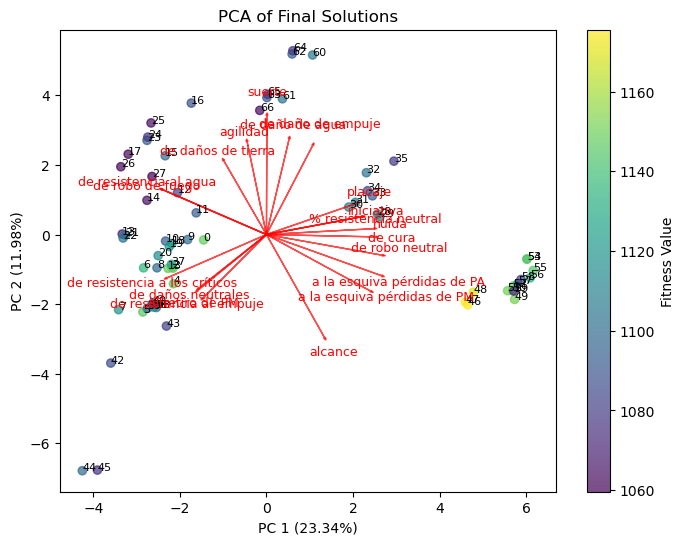

In [20]:
analyzer.plot_pca()

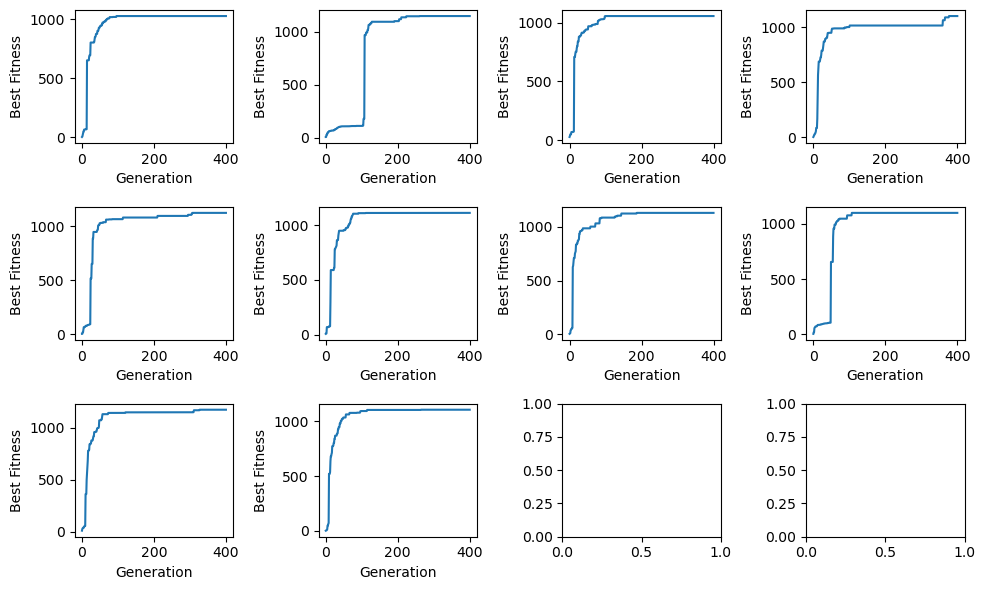

In [21]:
analyzer.report_generations()

In [10]:
assert False

AssertionError: 

In [ ]:
Items[Items["name"].str.contains("anillo de corrupc",case=False)]

,name,set,level
22205,Anillo de Corrupción,Set de Corrupción,200


In [ ]:
# Test
chr = Chromosome(
                  [
                      19984, 
                      # 11744,
                      14055,
                      22205, 22206, 19983, 15748, 30858, 30860, 15747, 8693, 7043, 7754,
                      13344, 13828, 13759, 694
                  ],
                 opt)
chr.fitness

1176.12

In [ ]:
Items[Items["name"].str.contains("ling",case=False)]

,name,set,level
15654,Frasco vacío del doctor Dil Linguer,None,180
15463,Lingote de Anutropía,None,100
15653,Frasco vacío del doctor Dil Linguer,None,180
13220,Fular de Explingon,None,1
19691,Pergamino traducido por Aisling,None,1
11744,Espada Lingüe,None,196
15655,Frasco vacío del doctor Dil Linguer,None,180
15652,Frasco vacío del doctor Dil Linguer,None,180
15569,Frasco vacío del doctor Dil Linguer,None,180
745,Lingote de oro,None,10


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)